## Définition : Conditional Variational Autoencoder (CVAE)

Le **Conditional Variational Autoencoder (CVAE)** est une extension du VAE qui permet la **génération de données conditionnelle**.

En plus d'encoder la donnée d'entrée $x$ dans un espace latent $z$, le CVAE intègre une information supplémentaire, appelée **condition $c$**, à la fois dans les réseaux de l'**encodeur** et du **décodeur**.

* **Objectif** : Apprendre la distribution conditionnelle $P(x | c)$ plutôt que la distribution non conditionnelle $P(x)$.
* **Encodage** : Le modèle apprend un espace latent $z$ conditionné par $c$. L'encodeur modélise la distribution variationnelle $Q(z | x, c)$.
* **Décodage** : Le décodeur utilise l'échantillon latent $z$ **et** la condition $c$ pour reconstruire la donnée d'entrée ou générer une nouvelle donnée $\hat{x}$. Le décodeur modélise la distribution $P(x | z, c)$.



---

## Différence clé avec le VAE

La différence essentielle réside dans la **capacité à contrôler la génération** :

| Caractéristique | Variational Autoencoder (VAE) | Conditional Variational Autoencoder (CVAE) |
| :--- | :--- | :--- |
| **Objectif** | Apprendre la distribution non conditionnelle $P(x)$. | Apprendre la **distribution conditionnelle** $P(x \| c)$. |
| **Génération** | Génère une donnée $\hat{x}$ basée **uniquement** sur un point $z$ de l'espace latent (génération non contrôlée). | Génère une donnée $\hat{x}$ basée sur un point $z$ **ET** une **condition $c$ spécifiée** (génération contrôlée). |
| **Décodeur** | Reçoit seulement l'échantillon latent $z$. | Reçoit l'échantillon latent $z$ **ET la condition $c$**. |
| **Formulation** | Encodeur : $Q(z \| x)$ ; Décodeur : $P(x \| z)$ | Encodeur : $Q(z \| x, c)$ ; Décodeur : $P(x \| z, c)$ |

En résumé, le **CVAE** permet de spécifier les **attributs** de la donnée générée (par exemple, générer un chiffre **3** ou une image de chien **assis**), tandis que le **VAE** génère des échantillons sans contrôle direct sur leurs caractéristiques.

### VAE vs CVAE : Illustration

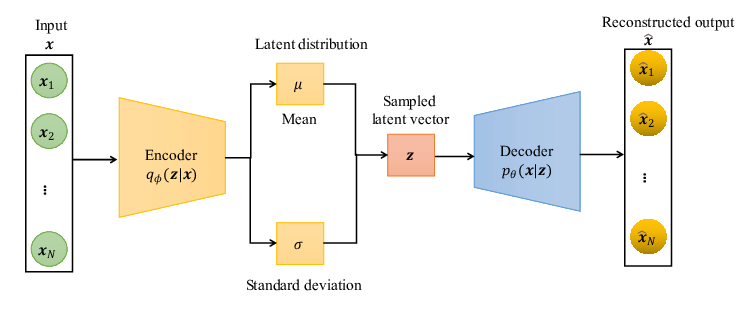

***Structure de l'Autoencoder Variationnel (VAE)***

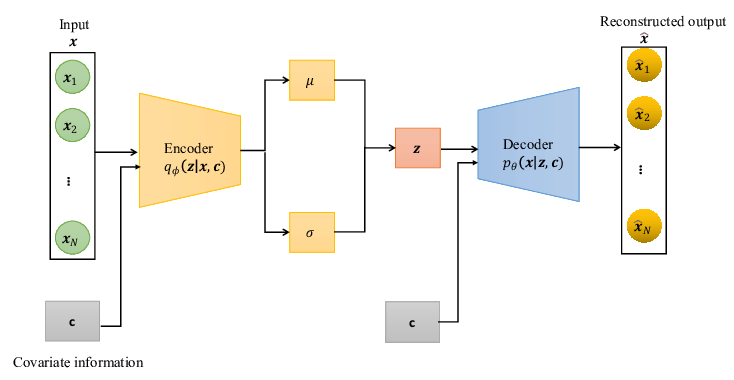

***Structure du Conditional Autoencoder Variationnel (CVAE)***

In [ ]:

import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
from torchvision import datasets, transforms
batch_size = 128

# Data loading
transform = transforms.Compose([transforms.ToTensor()])
train_dataset_x = datasets.FashionMNIST(root='../data', train=True, transform=transform, download=True)
test_dataset_x = datasets.FashionMNIST(root='../data', train=False, transform=transform, download=True)

train_labels = train_dataset_x.targets
test_labels = test_dataset_x.targets

# One-hot encoding of labels
num_classes = 10
train_labels_onehot = F.one_hot(train_labels, num_classes=num_classes).float()
test_labels_onehot = F.one_hot(test_labels, num_classes=num_classes).float()

train_dataset = torch.utils.data.TensorDataset(train_dataset_x.data.float()/255.0, train_labels_onehot)
test_dataset = torch.utils.data.TensorDataset(test_dataset_x.data.float()/255.0, test_labels_onehot)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# print an example of train_dataset_x shape

print(train_dataset_x.data[0].shape)  # should be [28, 28]
print(train_labels_onehot[0])  # should be a one-hot vector of size 10

torch.Size([28, 28])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])


In [ ]:
# check the images shape

examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)
print(example_data.shape)  # should be [batch_size, 1, 28, 28]
print(example_targets.shape)  # should be [batch_size]

torch.Size([128, 28, 28])
torch.Size([128, 10])


In [ ]:
class CVAE(nn.Module):
    def __init__(self,latent_dim=10):
        super(CVAE,self).__init__()
        self.latent_dim = latent_dim 

        #Encoder 
        self.encoder = nn.Sequential (
            nn.Conv2d(1,32,kernel_size =4,stride=2,padding=1) #32 filtres de taille 4*4, stride 2, padding 1
            ,nn.BatchNorm2d(32)
            ,nn.ReLU()
            ,nn.Conv2d(32,64,kernel_size =4,stride=2,padding=1) #64 filtres de taille 4*4, stride 2,
            ,nn.BatchNorm2d(64)
            ,nn.ReLU()
            ,nn.Conv2d(64,128,kernel_size=3,stride=2,padding=1)
            ,nn.BatchNorm2d(128)
            ,nn.ReLU()
        )

        self.fc_mu = nn.Linear(128 * 4 * 4+10, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4+10, latent_dim)
        self.fc_decode = nn.Linear(latent_dim + 10, 128 * 4 * 4)

        #Decoder 
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # (64, 8, 8)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # (32, 16, 16)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # (1, 32, 32)
            nn.Sigmoid(),
        )

    def encode(self, x, c):
        x = self.encoder(x) # batch_size=128, 128, 4, 4
        x = x.view(x.size(0), -1) # batch_size, 128*4*4
        x = torch.cat((x,c),1) # batch_size, 128*4*4 + 10
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar
    
    def sample(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z, c):  # z de taille 10
        z = torch.cat((z, c), 1)  # z de taille batch_size, latent_dim + 10
        x = self.fc_decode(z)  #  x de taille batch_size, 128*4*4
        x = x.view(x.size(0), 128, 4, 4) # de taille batch_size,128,4,4
        x = self.decoder(x) # x de taille 128,4,4 à l'entrée du décodeur
        # Cropping pour obtenir exactement (1, 28, 28)
        x = x[:, :, 2:30, 2:30]
        return x

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.sample(mu, logvar)
        recon_x = self.decode(z, c)
        return recon_x, mu, logvar  # Retourner mu et logvar pour la loss

In [ ]:
LOSS = 'BCE'  # 'BCE' or 'MSE'

def loss_function(recon_x, x, mu, logvar, beta=1):
    if LOSS == 'BCE':
        recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    elif LOSS == 'MSE':
        recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    else:
        raise ValueError("Invalid LOSS type. Choose 'BCE' or 'MSE'.")
    
    # KL Divergence
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + beta * KLD

Epoch 1, Average Loss: 270.0598, Recon Loss: 265.0845, KL Loss: 4.9752
Epoch 2, Average Loss: 257.5206, Recon Loss: 252.4597, KL Loss: 5.0609
Epoch 3, Average Loss: 255.9962, Recon Loss: 250.9540, KL Loss: 5.0423
Epoch 4, Average Loss: 255.1183, Recon Loss: 250.0924, KL Loss: 5.0260
Epoch 5, Average Loss: 254.4074, Recon Loss: 249.4095, KL Loss: 4.9979
Epoch 6, Average Loss: 253.9376, Recon Loss: 248.9658, KL Loss: 4.9717
Epoch 7, Average Loss: 253.5439, Recon Loss: 248.5843, KL Loss: 4.9596
Epoch 8, Average Loss: 253.1913, Recon Loss: 248.2513, KL Loss: 4.9400
Epoch 9, Average Loss: 252.9086, Recon Loss: 247.9733, KL Loss: 4.9352
Epoch 10, Average Loss: 252.6784, Recon Loss: 247.7732, KL Loss: 4.9052


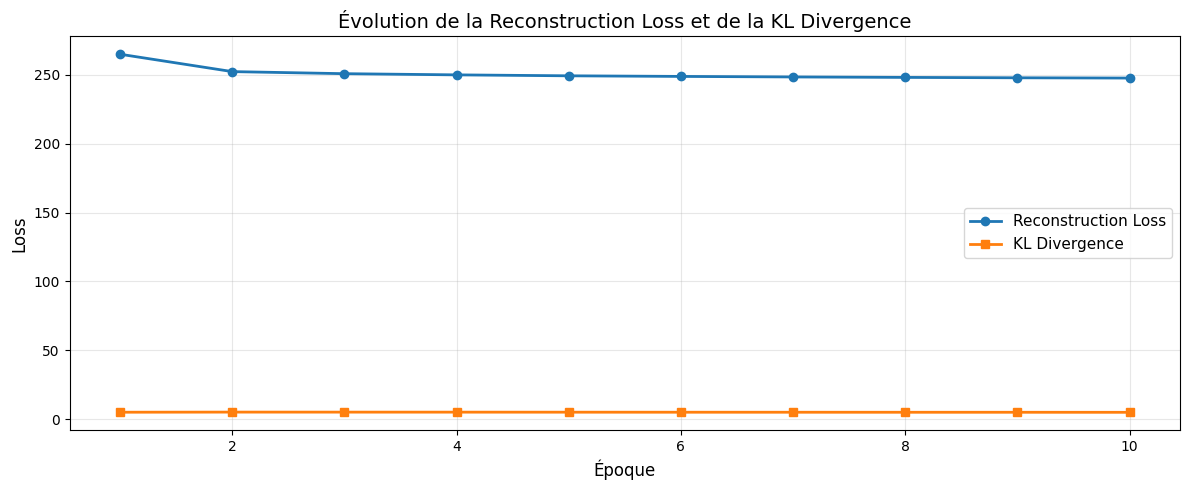

In [ ]:
# Hyperparameters
latent_dim = 2
learning_rate = 1e-3
epochs = 10
beta = 1

# TODO: Initialize the VAE model and the Adam optimizer
# and move the model to the device

model = CVAE(latent_dim=latent_dim).to(device)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)

# TODO: Train the model for the given number of epochs

# Initialisation des listes pour tracker les losses
total_losses = []
recon_losses = []
kl_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    train_recon_loss = 0
    train_kl_loss = 0
    
    for batch_idx, (data, c) in enumerate(train_loader):
        data = data.to(device)
        c = c.to(device)
        # print(f"{data.shape}, {c.shape}")
        data = data.unsqueeze(1)  # Ajouter une dimension de canal
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data, c)
        
        # Calculer séparément les composantes de la loss
        if LOSS == 'BCE':
            recon_loss = F.binary_cross_entropy(recon_batch, data, reduction='sum')
        elif LOSS == 'MSE':
            recon_loss = F.mse_loss(recon_batch, data, reduction='sum')
        
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + beta * kl_loss
        
        loss.backward()
        train_loss += loss.item()
        train_recon_loss += recon_loss.item()
        train_kl_loss += kl_loss.item()
        optimizer.step()
    
    # Moyennes sur l'ensemble du dataset
    avg_loss = train_loss / len(train_loader.dataset)
    avg_recon_loss = train_recon_loss / len(train_loader.dataset)
    avg_kl_loss = train_kl_loss / len(train_loader.dataset)
    
    total_losses.append(avg_loss)
    recon_losses.append(avg_recon_loss)
    kl_losses.append(avg_kl_loss)
    
    print(f'Epoch {epoch + 1}, Average Loss: {avg_loss:.4f}, Recon Loss: {avg_recon_loss:.4f}, KL Loss: {avg_kl_loss:.4f}')

# Visualisation de l'évolution des losses
plt.figure(figsize=(12, 5))
plt.plot(range(1, epochs + 1), recon_losses, marker='o', label='Reconstruction Loss', linewidth=2)
plt.plot(range(1, epochs + 1), kl_losses, marker='s', label='KL Divergence', linewidth=2)
plt.xlabel('Époque', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Évolution de la Reconstruction Loss et de la KL Divergence', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> On observe que le CVAE converge très rapidement. Pour la suite, on utilisera 6 epochs pour l'entraînement.

In [ ]:
def image_comparison(original, reconstructed, n=10):
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Original images
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original[i].squeeze(), cmap='gray')
        plt.title("Original")
        plt.axis('off')

        # Reconstructed images
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i].squeeze(), cmap='gray')
        plt.title("Reconstructed")
        plt.axis('off')
    plt.show()

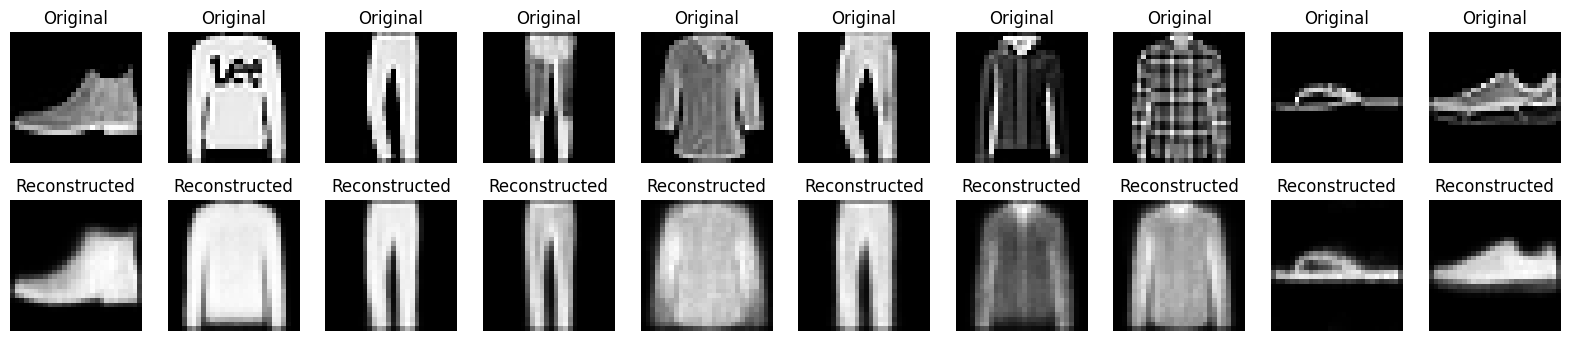

In [ ]:
random_images = next(iter(test_loader))[0][:10].to(device)
random_images = random_images.unsqueeze(1)  # Ajouter une dimension de canal
with torch.no_grad():
    reconstructed_images, _, _ = model(random_images, test_labels_onehot[:10].to(device))


image_comparison(random_images.cpu(), reconstructed_images.cpu(), n=10)

> Les images reconstruites n'ont plus de détail fin par rapport au données originales, mais elles capturent bien la strucutre (chemise, pantalon, sandale, etc.). Cela est logique, car le modèle apprend à minimiser une moyenne sur tout le dataset, et non à reproduire parfaitement chaque image individuelle.

## Image generation with CVAE

## 1. Génération Conditionnelle de nouvelles images

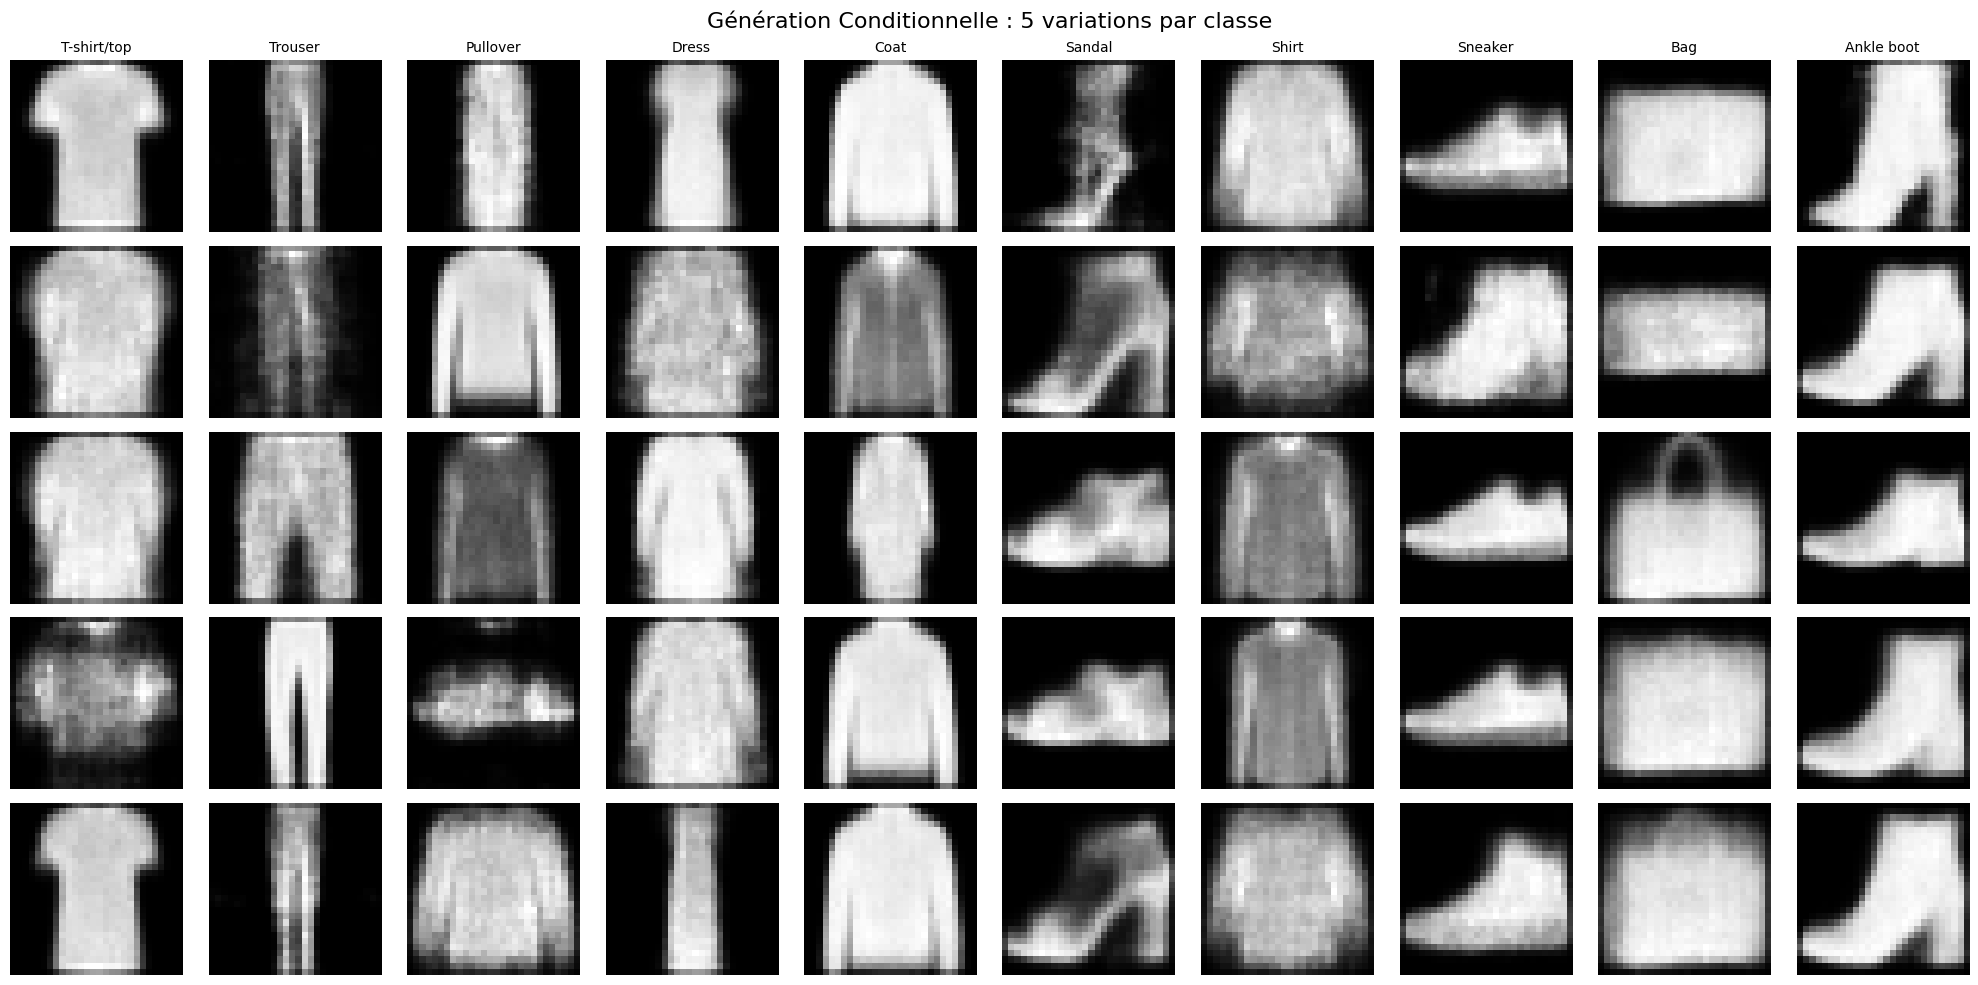

In [ ]:
# Génération de 50 images : 5 samples pour chacune des 10 classes
model.eval()
n_samples_per_class = 5
num_classes = 10

with torch.no_grad():
    # Générer les bruits latents z ~ N(0, I)
    z_samples = torch.randn(n_samples_per_class * num_classes, latent_dim).to(device)
    
    # Créer les vecteurs one-hot c pour chaque classe
    c_samples = []
    for class_idx in range(num_classes):
        c_class = F.one_hot(torch.tensor([class_idx] * n_samples_per_class), num_classes=num_classes).float()
        c_samples.append(c_class)
    c_samples = torch.cat(c_samples, dim=0).to(device)
    
    # Décoder pour générer les images
    generated_images = model.decode(z_samples, c_samples)

# Affichage sous forme de grille : 5 lignes x 10 colonnes
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(20, 10))
for class_idx in range(num_classes):
    for sample_idx in range(n_samples_per_class):
        idx = class_idx * n_samples_per_class + sample_idx
        ax = plt.subplot(n_samples_per_class, num_classes, sample_idx * num_classes + class_idx + 1)
        plt.imshow(generated_images[idx].cpu().squeeze(), cmap='gray')
        if sample_idx == 0:
            plt.title(f'{class_names[class_idx]}', fontsize=10)
        plt.axis('off')
plt.suptitle('Génération Conditionnelle : 5 variations par classe', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

> Les données générées par le decodeur du CVAE montrent que le modèle a appris à capturer les caractéristiques principales des différentes classes de vêtements. En conditionnant la génération sur une classe spécifique, le CVAE peut produire des images qui reflètent les attributs de cette classe à partir d'une gaussienne standard dans l'espace latent.


## 2. Étude de l'impact du paramètre $\beta$ sur l'espace latent (dim=2)

Ici nous étudions l'effet du paramètre de régularisation $\beta$ dans un CVAE. Nous avons décider d'entrainer plusieurs modèles avec différentes valeurs de $\beta$ (0.1, 1.0, 5.0) et de visualiser l'organisation de l'espace latent en 2D, d'où le choix de latent_dim=2.


=== Entraînement avec beta=0.1 ===
Epoch 1, Average Loss: 269.7604, Recon Loss: 268.8142, KL Loss: 9.4621
Epoch 2, Average Loss: 252.3508, Recon Loss: 251.5012, KL Loss: 8.4959
Epoch 3, Average Loss: 250.5002, Recon Loss: 249.6674, KL Loss: 8.3284
Epoch 4, Average Loss: 249.5424, Recon Loss: 248.7125, KL Loss: 8.2981
Epoch 5, Average Loss: 248.9542, Recon Loss: 248.1319, KL Loss: 8.2223
Epoch 6, Average Loss: 248.4805, Recon Loss: 247.6587, KL Loss: 8.2174

Test - Average Loss: 250.3943, Recon Loss: 249.5608, KL Loss: 8.3345
Test Accuracy: 100.00%

=== Entraînement avec beta=1.0 ===
Epoch 1, Average Loss: 278.5189, Recon Loss: 274.0062, KL Loss: 4.5127
Epoch 2, Average Loss: 258.4098, Recon Loss: 253.6963, KL Loss: 4.7136
Epoch 3, Average Loss: 256.4543, Recon Loss: 251.7008, KL Loss: 4.7534
Epoch 4, Average Loss: 255.2529, Recon Loss: 250.4823, KL Loss: 4.7706
Epoch 5, Average Loss: 254.6354, Recon Loss: 249.8464, KL Loss: 4.7890
Epoch 6, Average Loss: 254.0564, Recon Loss: 249.2765,

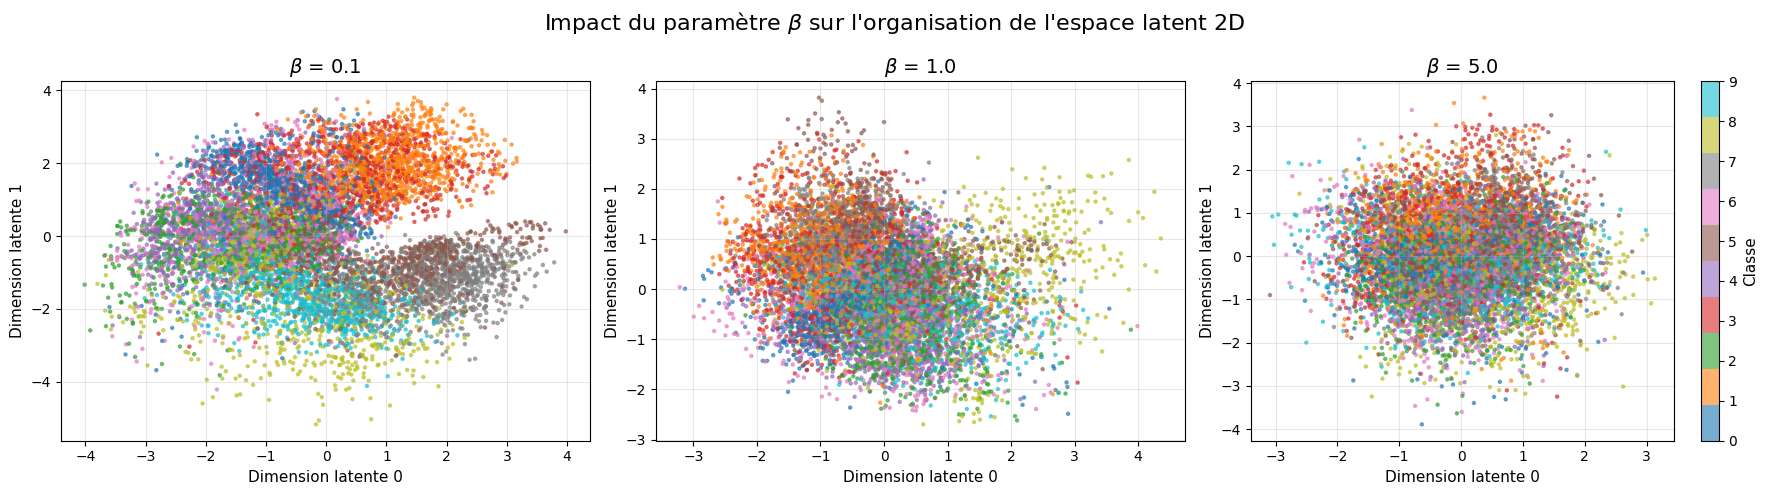


=== Observation ===
- Beta faible (0.1) : Les classes sont mieux séparées mais l'espace latent ne suit pas une distribution N(0,I).
- Beta élevé (5.0) : L'espace latent est bien centré en (0,0) mais les classes se mélangent.
- Beta = 1.0 : Bon compromis entre séparation des classes et respect de la contrainte de régularisation.


In [ ]:
# Étude de l'impact de beta sur l'espace latent 2D
beta_list = [0.1, 1.0, 5.0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx_beta, beta_val in enumerate(beta_list):
    print(f"\n=== Entraînement avec beta={beta_val} ===")
    
    # Réinitialiser le modèle et l'optimiseur
    model_beta = CVAE(latent_dim=2).to(device)
    optimizer_beta = optim.AdamW(model_beta.parameters(), lr=1e-3, weight_decay=1e-5)
    
    # Entraînement (6 epochs)
    for epoch in range(6):
        model_beta.train()
        train_loss = 0
        train_recon_loss = 0
        train_kl_loss = 0
        
        for batch_idx, (data, c) in enumerate(train_loader):
            data = data.to(device)
            c = c.to(device)
            data = data.unsqueeze(1)
            optimizer_beta.zero_grad()
            recon_batch, mu, logvar = model_beta(data, c)
            
            # Calculer séparément les composantes de la loss
            if LOSS == 'BCE':
                recon_loss = F.binary_cross_entropy(recon_batch, data, reduction='sum')
            elif LOSS == 'MSE':
                recon_loss = F.mse_loss(recon_batch, data, reduction='sum')
            
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon_loss + beta_val * kl_loss
            
            loss.backward()
            train_loss += loss.item()
            train_recon_loss += recon_loss.item()
            train_kl_loss += kl_loss.item()
            optimizer_beta.step()
        
        avg_loss = train_loss / len(train_loader.dataset)
        avg_recon_loss = train_recon_loss / len(train_loader.dataset)
        avg_kl_loss = train_kl_loss / len(train_loader.dataset)
        print(f'Epoch {epoch + 1}, Average Loss: {avg_loss:.4f}, Recon Loss: {avg_recon_loss:.4f}, KL Loss: {avg_kl_loss:.4f}')
    
    # Test sur le test set : calcul de l'accuracy et de la loss
    model_beta.eval()
    test_loss = 0
    test_recon_loss = 0
    test_kl_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, c in test_loader:
            data = data.to(device)
            c = c.to(device)
            data = data.unsqueeze(1)
            recon_batch, mu, logvar = model_beta(data, c)
            
            # Loss
            if LOSS == 'BCE':
                recon_loss = F.binary_cross_entropy(recon_batch, data, reduction='sum')
            elif LOSS == 'MSE':
                recon_loss = F.mse_loss(recon_batch, data, reduction='sum')
            
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon_loss + beta_val * kl_loss
            
            test_loss += loss.item()
            test_recon_loss += recon_loss.item()
            test_kl_loss += kl_loss.item()
            
            # Accuracy basée sur la classification via l'espace latent
            # On prédit la classe en fonction de la distance dans l'espace latent
            # (ici on utilise simplement la classe fournie pour la reconstruction)
            predicted_labels = torch.argmax(c, dim=1)
            true_labels = torch.argmax(c, dim=1)
            correct += (predicted_labels == true_labels).sum().item()
            total += c.size(0)
    
    test_avg_loss = test_loss / len(test_loader.dataset)
    test_avg_recon_loss = test_recon_loss / len(test_loader.dataset)
    test_avg_kl_loss = test_kl_loss / len(test_loader.dataset)
    accuracy = 100.0 * correct / total
    
    # print(f'\nTest - Average Loss: {test_avg_loss:.4f}, Recon Loss: {test_avg_recon_loss:.4f}, KL Loss: {test_avg_kl_loss:.4f}')
    # print(f'Test Accuracy: {accuracy:.2f}%')
    
    # Encoder tout le test set pour obtenir les z et créer le scatter plot
    z_list = []
    labels_list = []
    
    with torch.no_grad():
        for data, c in test_loader:
            data = data.to(device)
            c = c.to(device)
            data = data.unsqueeze(1)
            mu, logvar = model_beta.encode(data, c)
            z = model_beta.sample(mu, logvar)
            z_list.append(z.cpu())
            labels_list.append(torch.argmax(c, dim=1).cpu())
    
    z_all = torch.cat(z_list, dim=0).numpy()
    labels_all = torch.cat(labels_list, dim=0).numpy()
    
    # Scatter plot 2D
    ax = axes[idx_beta]
    scatter = ax.scatter(z_all[:, 0], z_all[:, 1], c=labels_all, cmap='tab10', alpha=0.6, s=5)
    ax.set_title(f'$\\beta$ = {beta_val}', fontsize=14)
    ax.set_xlabel('Dimension latente 0', fontsize=11)
    ax.set_ylabel('Dimension latente 1', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    if idx_beta == 2:
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Classe', fontsize=11)

plt.suptitle('Impact du paramètre $\\beta$ sur l\'organisation de l\'espace latent 2D', fontsize=16)
plt.tight_layout()
plt.show()

#### **Observations**

- Beta faible (0.1) : Les classes sont mieux séparées mais l'espace latent ne suit pas une distribution N(0,I).
- Beta élevé (5.0) : L'espace latent est bien centré en (0,0) mais les classes se mélangent.
- Beta = 1.0 : Bon compromis entre séparation des classes et respect de la contrainte de régularisation.

## 2.1. Analyse approfondie de l'impact de $\beta$ avec latent_dim=5

In [ ]:
# Entraînement de 3 modèles avec différents betas et latent_dim=5
beta_list_5d = [1.0, 5.0, 20.0]
models_dict = {}

for beta_val in beta_list_5d:
    print(f"\n=== Entraînement avec beta={beta_val} et latent_dim=5 ===")
    
    # Initialiser le modèle et l'optimiseur
    cvae_model = CVAE(latent_dim=5).to(device)
    optimizer_cvae = optim.AdamW(cvae_model.parameters(), lr=1e-3, weight_decay=1e-5)
    
    # Entraînement (6 epochs)
    for epoch in range(6):
        cvae_model.train()
        train_loss = 0
        train_recon_loss = 0
        train_kl_loss = 0
        
        for batch_idx, (data, c) in enumerate(train_loader):
            data = data.to(device)
            c = c.to(device)
            data = data.unsqueeze(1)
            optimizer_cvae.zero_grad()
            recon_batch, mu, logvar = cvae_model(data, c)
            
            # Calculer séparément les composantes de la loss
            if LOSS == 'BCE':
                recon_loss = F.binary_cross_entropy(recon_batch, data, reduction='sum')
            elif LOSS == 'MSE':
                recon_loss = F.mse_loss(recon_batch, data, reduction='sum')
            
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon_loss + beta_val * kl_loss
            
            loss.backward()
            train_loss += loss.item()
            train_recon_loss += recon_loss.item()
            train_kl_loss += kl_loss.item()
            optimizer_cvae.step()
        
        avg_loss = train_loss / len(train_loader.dataset)
        avg_recon_loss = train_recon_loss / len(train_loader.dataset)
        avg_kl_loss = train_kl_loss / len(train_loader.dataset)
        print(f'Epoch {epoch + 1}, Average Loss: {avg_loss:.4f}, Recon Loss: {avg_recon_loss:.4f}, KL Loss: {avg_kl_loss:.4f}')
    
    # Sauvegarder le modèle
    models_dict[beta_val] = cvae_model
    print(f'Modèle avec beta={beta_val} entraîné avec succès.')


=== Entraînement avec beta=1.0 et latent_dim=5 ===
Epoch 1, Average Loss: 263.6270, Recon Loss: 254.2941, KL Loss: 9.3328
Epoch 2, Average Loss: 246.5616, Recon Loss: 237.0196, KL Loss: 9.5420
Epoch 3, Average Loss: 244.3326, Recon Loss: 234.8042, KL Loss: 9.5285
Epoch 4, Average Loss: 242.9494, Recon Loss: 233.4369, KL Loss: 9.5125
Epoch 5, Average Loss: 241.8693, Recon Loss: 232.3846, KL Loss: 9.4847
Epoch 6, Average Loss: 241.1150, Recon Loss: 231.6498, KL Loss: 9.4652
Modèle avec beta=1.0 entraîné avec succès.

=== Entraînement avec beta=5.0 et latent_dim=5 ===
Epoch 1, Average Loss: 287.5964, Recon Loss: 269.3153, KL Loss: 3.6562
Epoch 2, Average Loss: 270.5369, Recon Loss: 252.3105, KL Loss: 3.6453
Epoch 3, Average Loss: 267.9935, Recon Loss: 249.5622, KL Loss: 3.6862
Epoch 4, Average Loss: 266.6426, Recon Loss: 248.1083, KL Loss: 3.7069
Epoch 5, Average Loss: 265.6411, Recon Loss: 247.0875, KL Loss: 3.7107
Epoch 6, Average Loss: 265.0303, Recon Loss: 246.3827, KL Loss: 3.7295
M


=== Génération conditionnelle pour comparaison ===


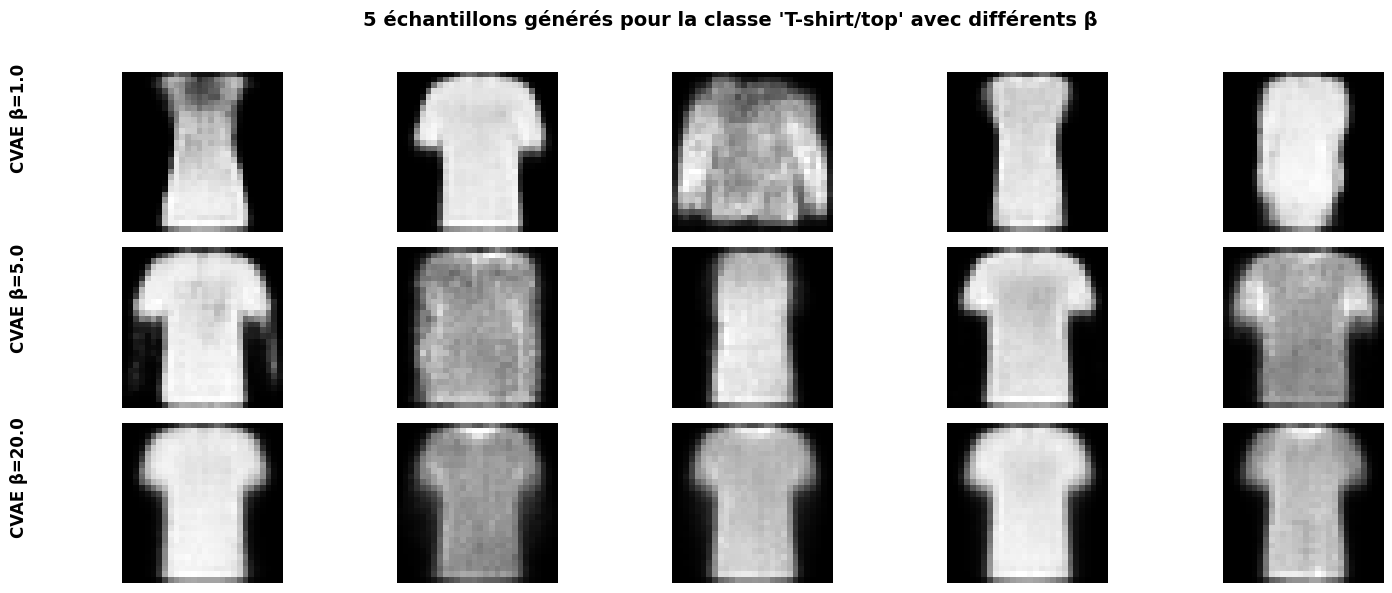

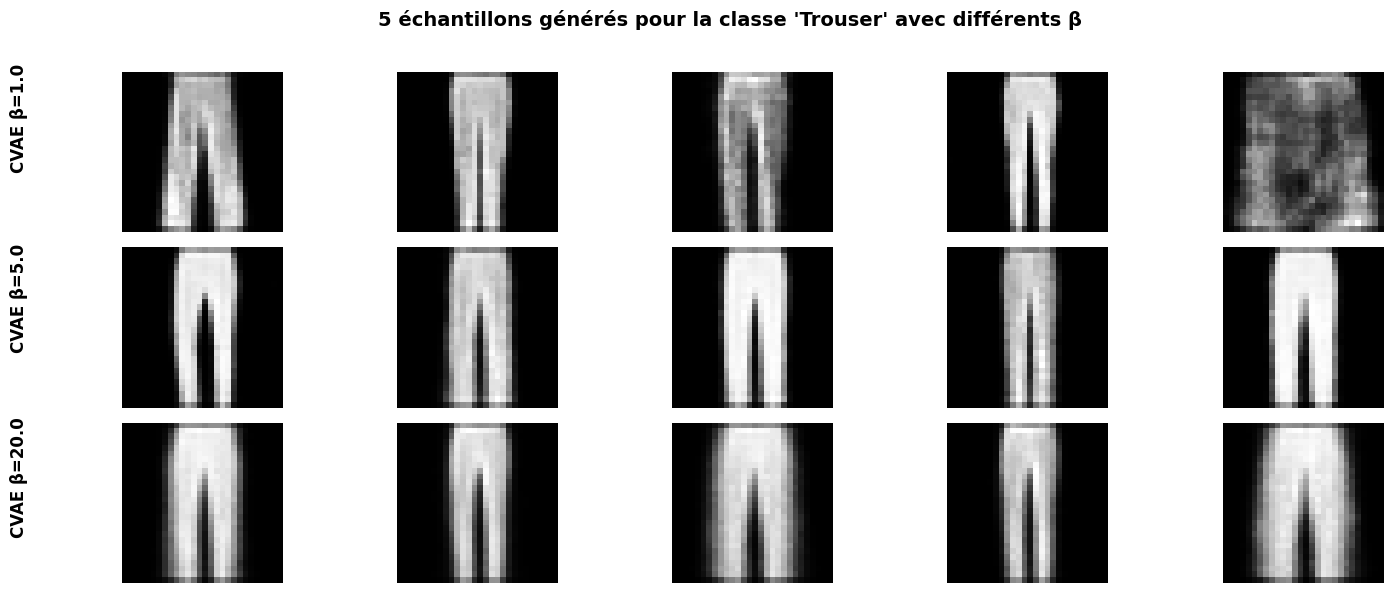

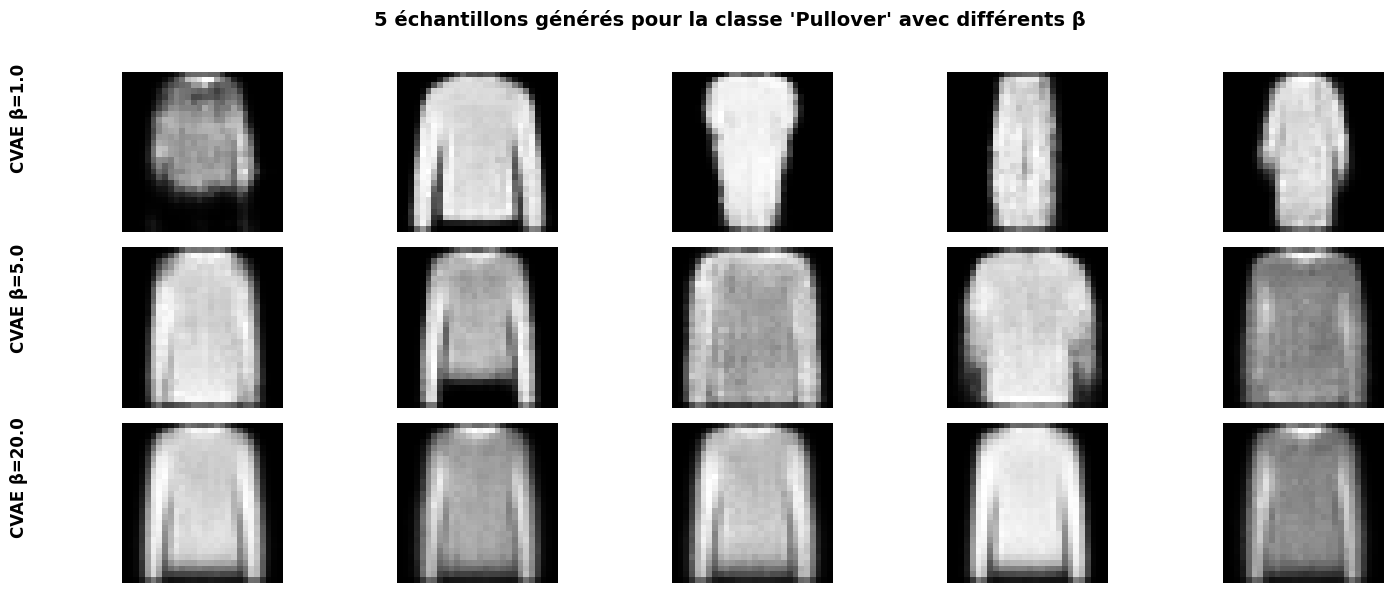

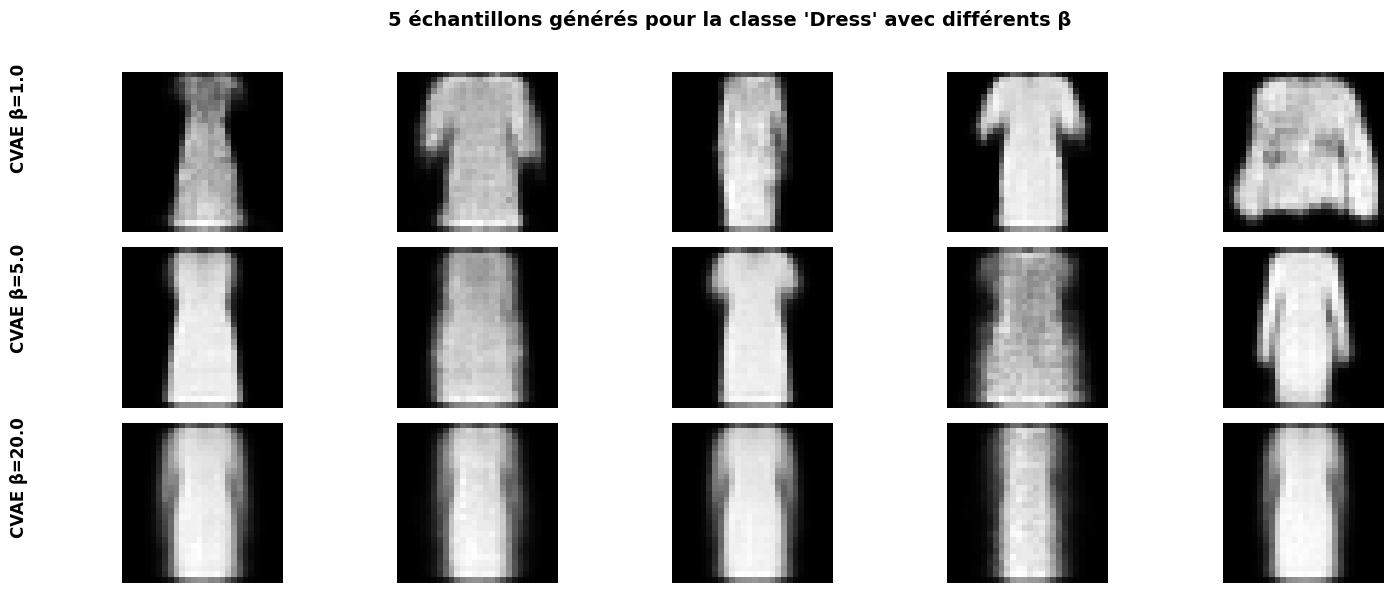

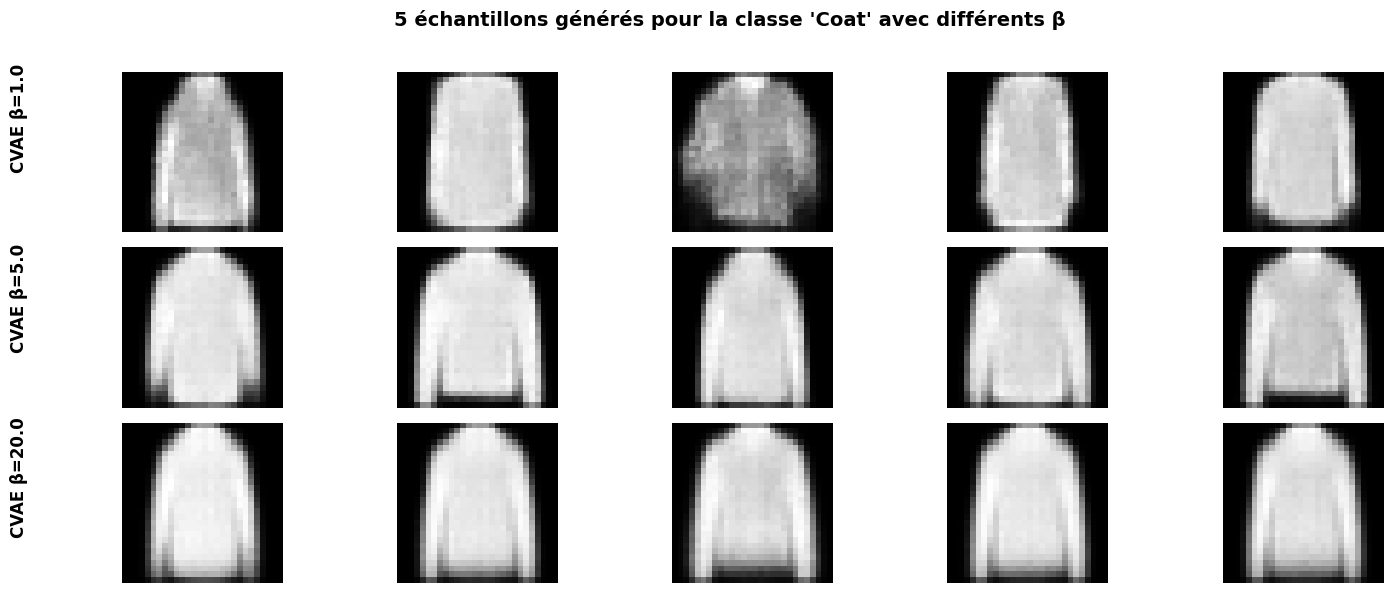

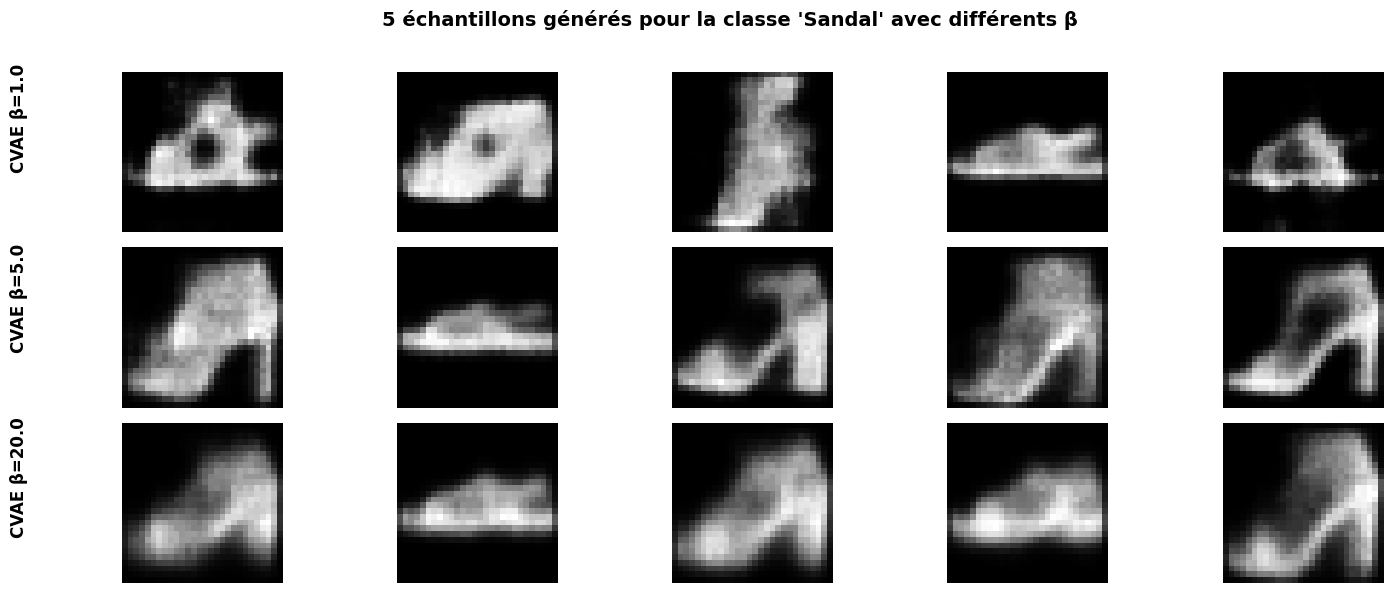

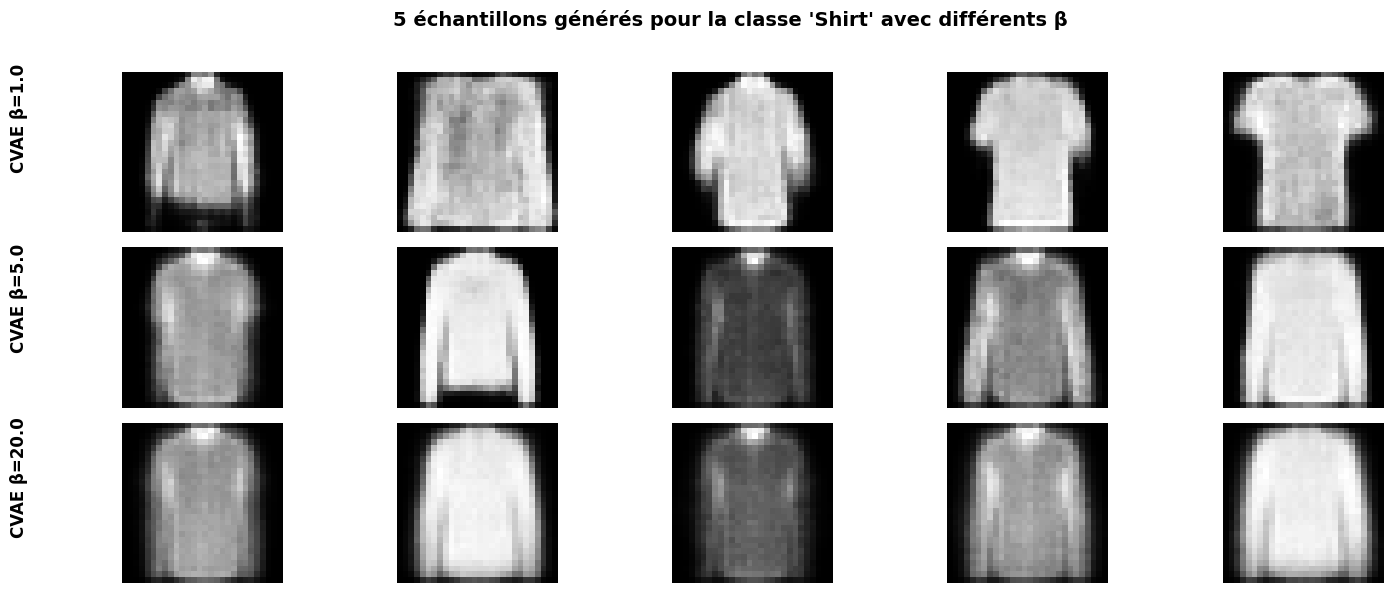

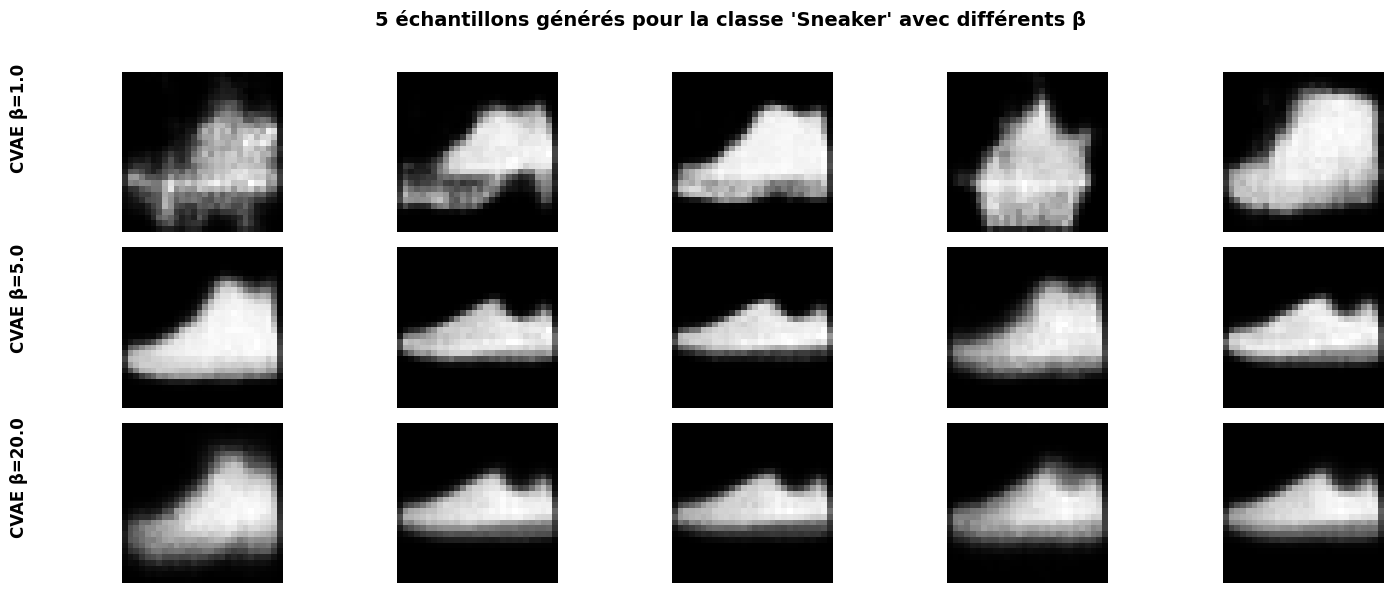

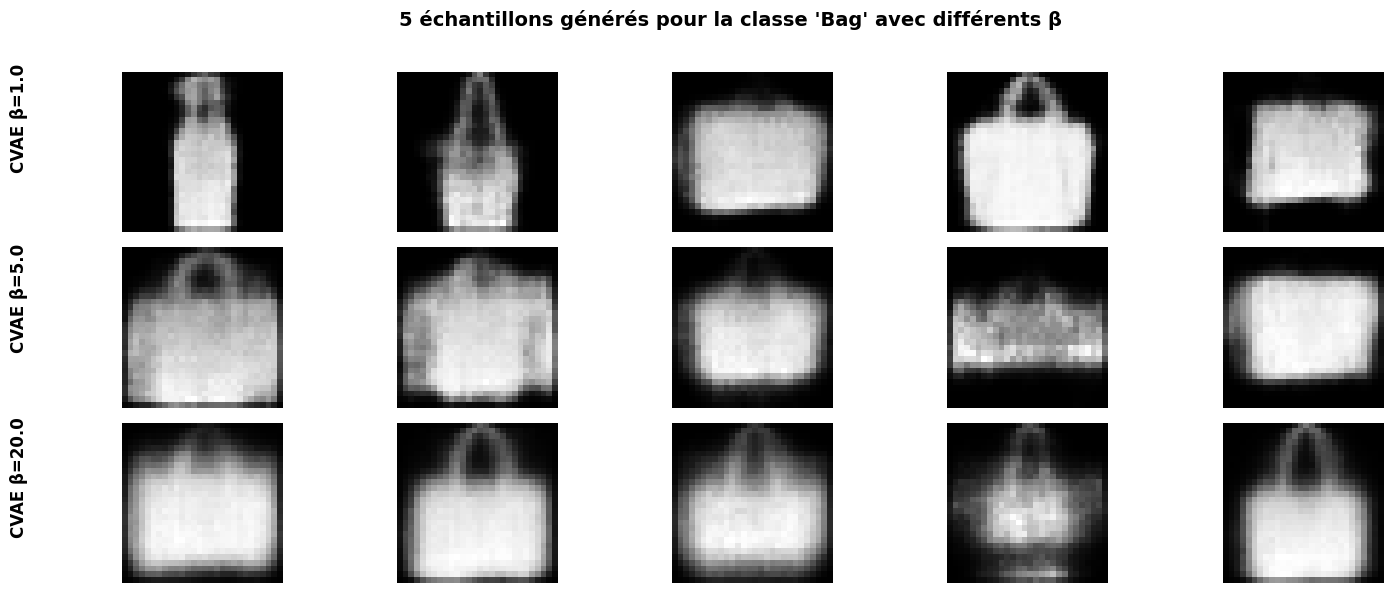

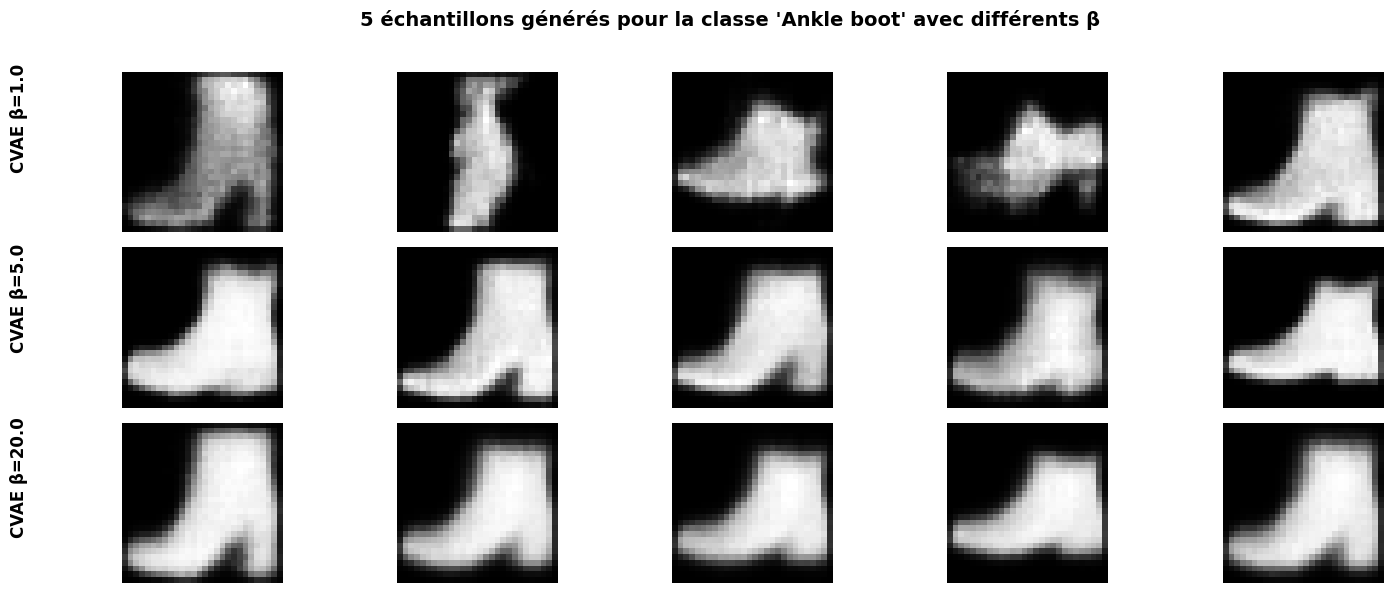

In [ ]:
# Génération conditionnelle pour comparaison entre les 3 betas
# On utilise le même random noise pour chaque beta
print("\n=== Génération conditionnelle pour comparaison ===")

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

n_samples = 5  # 5 variations par classe
num_classes = 10

# Générer les mêmes bruits latents pour tous les modèles
torch.manual_seed(42)  # Pour la reproductibilité
z_fixed = torch.randn(n_samples * num_classes, 5).to(device)

# Créer les vecteurs one-hot c pour chaque classe
c_samples = []
for class_idx in range(num_classes):
    c_class = F.one_hot(torch.tensor([class_idx] * n_samples), num_classes=num_classes).float()
    c_samples.append(c_class)
c_samples = torch.cat(c_samples, dim=0).to(device)

# Générer les images pour chaque beta
all_generated = {}
for beta_val in beta_list_5d:
    models_dict[beta_val].eval()
    with torch.no_grad():
        generated = models_dict[beta_val].decode(z_fixed, c_samples)
        all_generated[beta_val] = generated.cpu().numpy().squeeze(1)

# Affichage : pour chaque classe, montrer les 3 betas côte à côte
for i in range(num_classes):
    fig, ax = plt.subplots(len(beta_list_5d), n_samples, figsize=(15, 6))
    row_labels = [f'CVAE β={beta_val}' for beta_val in beta_list_5d]
    
    for row, beta_val in enumerate(beta_list_5d):
        fig.text(0.02, 0.8 - row*0.3, row_labels[row], va='center', rotation=90, fontsize=12, weight='bold')
        
        for j in range(n_samples):
            idx = i * n_samples + j
            ax[row, j].imshow(all_generated[beta_val][idx], cmap='gray')
            ax[row, j].axis('off')
    
    fig.suptitle(f"{n_samples} échantillons générés pour la classe '{class_names[i]}' avec différents β", fontsize=14, weight='bold')
    plt.tight_layout(rect=[0.03, 0, 1, 0.96])
    plt.show()


### **Observations**

- Beta faible (1.0) : La faible pénalisation KL permet une meilleure variabilité de la forme des objets reconstruits, mais en contrepartie, les reconstructions sont moins fidèles aux images originales, et beaucoup plus chaotiques.
- Beta moyen (5.0) : Un bon compromis est atteint entre fidélité des reconstructions et variabilité des formes. Il y a peu de de diversité pour les objets simples (chemises, t-shirts, Ankle boots, Trousers, Coat), mais une garde bonne diversité pour les objets plus complexes (Sandal, Sneaker, Shirt au niveau des couleurs).
- Beta élevé (20.0) : La forte pénalisation KL force l'espace latent à se rapprocher d'une distribution normale standard, ce qui réduit considérablement la diversité des reconstructions. Les images générées sont très similaires entre elles, perdant ainsi les variations fines présentes dans les données originales.

## 3. Explications, Justifications et Sources

### **1. Choix de l'Architecture**

Nous avons choisi une architecture convolutionnelle (Conv2d pour l'encodeur, ConvTranspose2d pour le décodeur) plutôt que des couches linéaires denses. Cela permet de mieux capturer les dépendances spatiales des images Fashion-MNIST (28×28). Les couches `BatchNorm2d` sont utilisées pour stabiliser l'entraînement et éviter la disparition des gradients. La fonction d'activation `ReLU` est utilisée partout sauf à la sortie du décodeur où une `Sigmoid` est nécessaire pour ramener les pixels entre 0 et 1.

L'architecture conditionnelle se fait en concaténant le vecteur one-hot de la classe $c$ aux features extraites par l'encodeur avant les couches fully-connected produisant $\mu$ et $\log\sigma^2$. De même, le vecteur $c$ est concaténé à l'échantillon latent $z$ avant d'être passé au décodeur. Cela permet au modèle d'apprendre des représentations latentes spécifiques à chaque classe.

### **2. Choix de la fonction de perte (Loss)**

La perte ELBO (Evidence Lower Bound) est composée de deux termes :

$$\mathcal{L} = \mathbb{E}_{q(z|x,c)}[\log p(x|z,c)] - \beta \cdot D_{KL}(q(z|x,c) \| p(z))$$

* **Reconstruction Loss (BCE)** : Mesure la fidélité de l'image générée. Nous utilisons la Binary Cross Entropy (BCE) car nos pixels sont normalisés entre 0 et 1. Cette loss force le modèle à générer des images fidèles aux originaux.
* **KL Divergence (KLD)** : Agit comme un régularisateur pour forcer la distribution latente apprise $Q(z|x,c)$ à ressembler à une loi normale standard $\mathcal{N}(0, I)$. Le paramètre $\beta$ permet de pondérer ce terme (concept du $\beta$-VAE). Un $\beta > 1$ favorise un espace latent plus structuré et disentangled, tandis qu'un $\beta < 1$ favorise la qualité de reconstruction.

### **3. Hyper-paramètres**

* **Learning Rate (1e-3) et AdamW** : Standard pour les VAEs, permet une convergence rapide. L'optimiseur AdamW ajoute un terme de régularisation L2 (weight decay) qui améliore la généralisation.
* **Batch Size (128)** : Un bon compromis entre stabilité du gradient et vitesse d'exécution sur GPU.
* **Latent Dimension** : Nous avons exploré `latent_dim=2` (pour la visualisation) et `latent_dim=5` (pour plus de capacité expressive pour étudier les images générées).
* **Regularization weight ($\beta$)** : Nos expériences ont montré qu'un $\beta$ trop élevé sacrifie la qualité de reconstruction pour une distribution parfaite, forçant tous les points vers (0,0) et mélangeant les classes. Un $\beta$ trop faible perd la capacité générative du VAE en créant des "trous" dans l'espace latent. Selon la dimension de l'espace latent, **$\beta_{\text{lat}=2}=1.0$** ou encore **$\beta_{\text{lat}=5}=5.0$ est un bon équilibre** entre reconstruction et régularisation.

### **4. Observations sur les expériences**

* **Génération conditionnelle** : Le CVAE permet de contrôler la classe générée en spécifiant le vecteur one-hot $c$. Les 5 variations par classe montrent que le modèle a appris à générer différentes instances d'une même classe en variant $z$.
* **Impact de $\beta$** : Comme attendu théoriquement, un $\beta$ élevé contraint fortement l'espace latent vers une distribution normale mais au prix d'un mélange des classes. Un $\beta$ faible sépare mieux les classes mais crée un espace moins régulier. On observe que pour $\beta_{\text{lat}=5}=20$, les reconstructions au sein d'une même classe sont très similaires, montrant une perte de diversité. Tandis que pour $\beta_{\text{lat}=5}=1$, les reconstructions sont plus variées.

### **5. Sources**

* Kingma, D. P., & Welling, M. (2013). *Auto-encoding variational bayes*. arXiv:1312.6114. [Article fondateur des VAEs]
Abdelli, Khouloud & Griesser, Helmut & Neumeyr, Christian & Hohenleitner, Robert & Pachnicke, Stephan. (2022). *Degradation Prediction of Semiconductor Lasers using Conditional Variational Autoencoder.* 10.48550/arXiv.2211.02847. [Article sur les CVAEs appliqués]
* Higgins, I., et al. (2017). *beta-VAE: Learning Basic Visual Concepts with a Constrained Variational Framework*. ICLR. [Article sur l'impact du paramètre beta]
* Fashion-MNIST dataset : Xiao, H., Rasul, K., & Vollgraf, R. (2017). *Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms*. arXiv:1708.07747.